# Fundamentals 
---
## 📘 02 — Building and Modifying Figures
## 🧠 Core Idea

* A Plotly figure is not just something you create once — it’s something you build, refine, and evolve step-by-step.

## 1. 📘 Overview

* After understanding that a figure is a structured object, the next step is learning how to construct and manipulate it effectively.

Plotly provides multiple ways to create figures — from quick high-level APIs to detailed low-level control. Once created, figures can be updated dynamically by modifying traces, layouts, and properties.

This flexibility is what makes Plotly powerful for both exploratory analysis and production dashboards.

###  🚀 What We’ll Cover

1. ***Figures As Dictionaries***  — understand figures as structured Python dictionaries
2. ***Figures as Graph Objects*** — work with object-oriented figure representations
3. ***Converting Graph Objects To Dictionaries and JSON*** — transform figures for storage and web use
4. ***Representing Figures in Dash*** — integrate figures into Dash applications
5. ***Creating Figures*** — explore different ways to initialize figures
6. ***Plotly Express*** — build quick, high-level visualizations
7. ***Graph Objects Figure Constructor*** — create fully customizable figures
8. ***Figure Factories*** — generate complex prebuilt visualizations
9. ***Adding Traces To Subplots*** — position traces within subplot grids
10. ***Magic Underscore Notation*** — simplify nested updates
11. ***Updating Traces*** — modify visual properties of traces
12. ***Other Update Methods*** — explore additional update techniques

 ---

In [56]:
import plotly.express as px
import plotly.graph_objects as go 
from  plotly.subplots import make_subplots
import plotly.io as pio
import json
import numpy as np
import plotly.figure_factory as ff
from dash import Dash , dcc , html , Input , Output

import numpy as np 
import warnings
warnings.filterwarnings('ignore')

# 📘 1. Figures as Dictionaries — Key Working Points
# > 🔹 Core Idea
1. A Plotly figure is just a Python dictionary (dict)
2. It has 3 main keys:
* data → what to plot (traces)
* layout → how it looks (title, axes, styling)
* frames → used for animations (optional)

In [2]:
# basic structure 
data: {
    'data' : [...],
    'layout' : {...},
    'frames' : [...]
}

## 🔹 Creating Figure from Dict

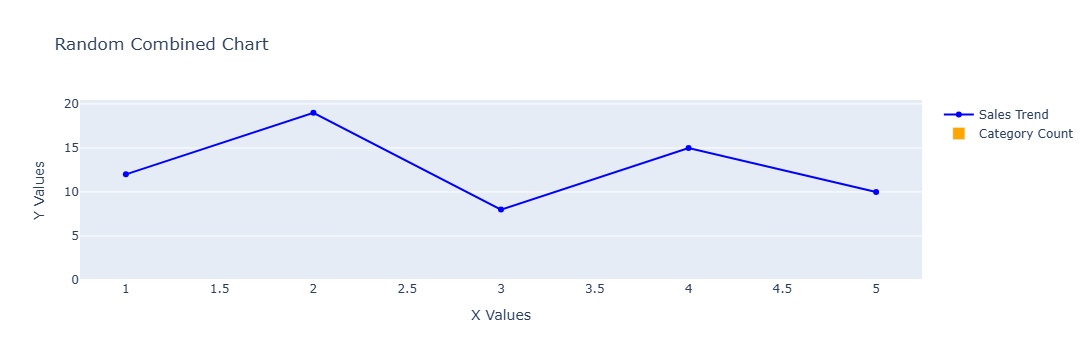

In [112]:
# import plotly.io as pio
fig = {
    "data": [
        {
            "type": "scatter",
            "mode": "lines+markers",
            "x": [1, 2, 3, 4, 5],
            "y": [12, 19, 8, 15, 10],
            "name": "Sales Trend",
            "line": {"color": "blue"}
        },
        {
            "type": "bar",
            "x": ["A", "B", "C", "D"],
            "y": [5, 9, 3, 7],
            "name": "Category Count",
            "marker": {"color": "orange"}
        }
    ],
    "layout": {
        "title": "Random Combined Chart",
        "xaxis": {"title": "X Values"},
        "yaxis": {"title": "Y Values"},
        "showlegend": True
    }
}
# pio.show(fig)
fig_obj = go.Figure(fig) 

fig_obj.show()

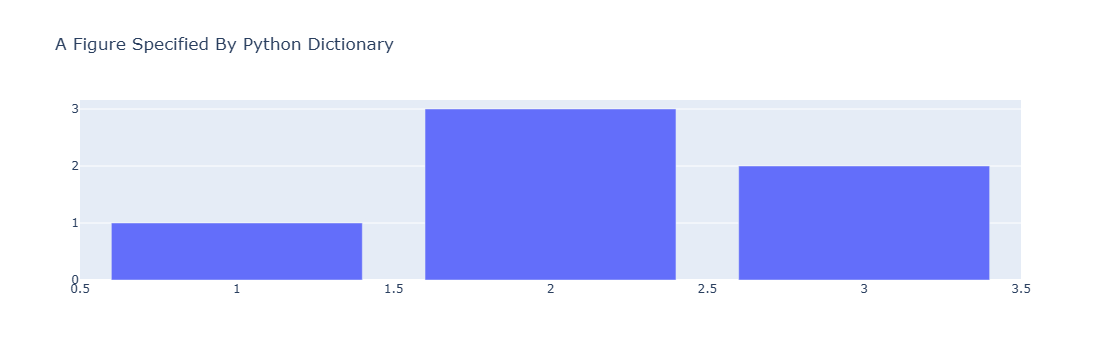

In [4]:
fig = dict({
    "data": [{"type": "bar",
              "x": [1, 2, 3],
              "y": [1, 3, 2]}],
    "layout": {"title": {"text": "A Figure Specified By Python Dictionary"}}
})

# To display the figure defined by this dict, use the low-level plotly.io.show function
import plotly.io as pio

pio.show(fig)

## 🔹 Mental Model
* Figure = Blueprint (dict) → Plotly renders it into visuals
---

# 🧊 2: Figures as Graph Objects
## ⚡ Simple Idea First

* Instead of building plots using raw dictionaries like this:
>  Plotly gives you a structured, object-oriented way using
1. plotly.graph_objects (commonly imported as go)
> 🧠 What is a Graph Object?

* A Graph Object is basically a Python class representation of a chart.

> Think of it like:

1. 👉 Instead of writing raw JSON/dict
2. 👉 You use ready-made classes with validation + intelligence

## 🏗️ Main Class

In [5]:
# import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=[1, 2, 3],
    y=[10, 20, 30],
    mode='lines',
    name='Line Chart'
))

fig.update_layout(
    title="My First Graph Object Chart",
    xaxis_title="X Axis",
    yaxis_title="Y Axis",
    template="plotly_dark",
)


# fig = go.Figure(layout=dict(
#     title = dict(
#         text = 'My Chart'
#     )
# ))
fig = go.Figure(layout_title_text = 'My Chart')
fig.show()

# Step 1: Create Figure 
fig = go.Figure(
    layout_title_text="📊 Combined Graph Objects Example"
)

# Step 2: Add Line Trace
fig.add_trace(go.Scatter(
    x=[1, 2, 3, 4],
    y=[10, 15, 13, 17],
    mode='lines',
    name='Line Chart',
    line=dict(color='blue', width=3)
))

# Step 3: Add Marker Trace
fig.add_trace(go.Scatter(
    x=[1, 2, 3, 4],
    y=[16, 5, 11, 9],
    mode='markers',
    name='Marker Chart',
    marker=dict(color='red', size=10)
))

# Step 4: Update Layout (axes, theme, legend)
fig.update_layout(
    xaxis_title="X Axis",
    yaxis_title="Y Axis",
    template="plotly_dark",   
    legend_title_text="Legend"
)

# Step 5: Update Traces 
fig.update_traces(
    marker=dict(line=dict(width=2, color='white'))
)

fig.show()

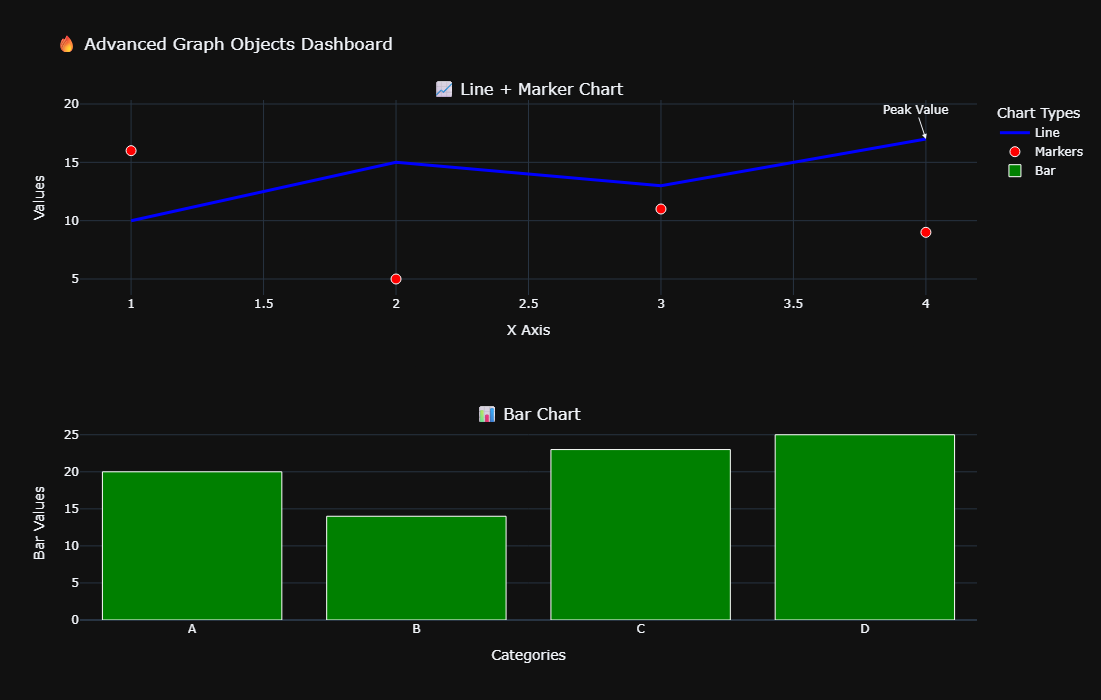

In [6]:
# Step 1: Create Subplots (2 rows, 1 column)
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("📈 Line + Marker Chart", "📊 Bar Chart")
)

# Step 2: Add Line Trace
fig.add_trace(go.Scatter(
    x=[1, 2, 3, 4],
    y=[10, 15, 13, 17],
    mode='lines',
    name='Line',
    line=dict(color='blue', width=3),
    hovertemplate="X: %{x}<br>Y: %{y}<extra>Line</extra>" # using hover templete with the doc
), row=1, col=1)

# Step 3: Add Marker Trace
fig.add_trace(go.Scatter(
    x=[1, 2, 3, 4],
    y=[16, 5, 11, 9],
    mode='markers',
    name='Markers',
    marker=dict(color='red', size=10),
    hovertemplate="Value: %{y}<extra>Markers</extra>"
), row=1, col=1)

# Step 4: Add Bar Chart
fig.add_trace(go.Bar(
    x=["A", "B", "C", "D"],
    y=[20, 14, 23, 25],
    name='Bar',
    marker=dict(color='green'),
    hovertemplate="Category: %{x}<br>Value: %{y}<extra>Bar</extra>"
), row=2, col=1)

# Step 5: Add Annotation
fig.add_annotation(
    text="Peak Value",
    x=4, y=17,
    showarrow=True,
    arrowhead=2,
    row=1, col=1
)

# Step 6: Update Layout 
fig.update_layout(
    title_text="🔥 Advanced Graph Objects Dashboard",
    template="plotly_dark",
    height=700,
    legend_title_text="Chart Types"
)

# Step 7: Update Axes
fig.update_xaxes(title_text="X Axis", row=1, col=1)
fig.update_yaxes(title_text="Values", row=1, col=1)

fig.update_xaxes(title_text="Categories", row=2, col=1)
fig.update_yaxes(title_text="Bar Values", row=2, col=1)

# Step 8: Global Trace Update
fig.update_traces(
    marker=dict(line=dict(width=1, color='white'))
)

fig.show()


## ⚡ One-Line Summary

> Graph Objects = structured, powerful, and validated way to build Plotly figures using Python classes instead of raw 
---

#  🗃️ 3. Converting Graph Objects to Dictionary & JSON
## 🧠 Core Idea

>  A Plotly figure is not magic. Internally, it’s just:

1.  A Python dictionary
2.  That can also be converted into JSON

In [19]:
fig = go.Figure(
    data = [go.Bar(x=[1, 2, 3], y=[1, 3, 2])],
    layout = go.Layout(height = 600 , width = 800),
    
)

fig.layout.template = None

fig_dict = fig.to_dict()
print(fig_dict)
#  What this means
# data → contains all traces (your graph)
# layout → contains design & styling

{'data': [{'x': [1, 2, 3], 'y': [1, 3, 2], 'type': 'bar'}], 'layout': {'height': 600, 'width': 800}}


In [8]:
fig_json = fig.to_json()
print(fig_json)

{"data":[{"x":[1,2,3],"y":[1,3,2],"type":"bar"}],"layout":{"height":600,"width":800}}


## ✅ 1. Dash uses JSON internally

> When you build apps with Dash:

In [9]:
dash = dcc.Graph(figure = fig)
dash

Graph(figure=Figure({
    'data': [{'type': 'bar', 'x': [1, 2, 3], 'y': [1, 3, 2]}], 'layout': {'height': 600, 'width': 800}
}))

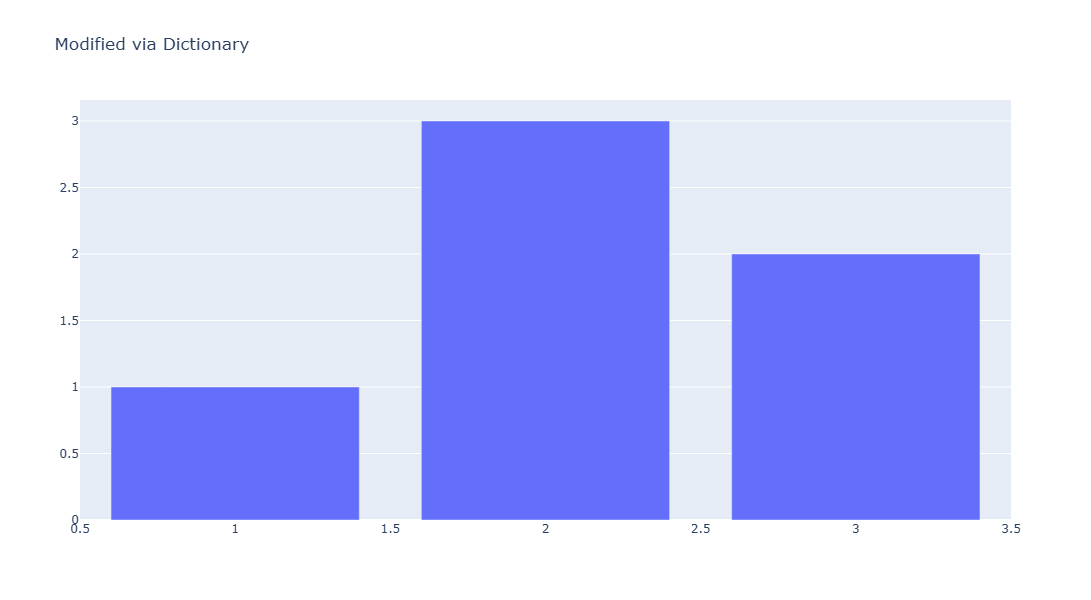

In [10]:
# Modify dictionary
fig_dict["layout"]["title"] = "Modified via Dictionary"

# Convert back to figure (CORRECT WAY)
new_fig = go.Figure(fig_dict)
new_fig.show()

# 📊 4. Representing Figures in Dash
---
1. Create a Plotly Figure
2. Initialize Dash App
3. Define Layout
4. Add Callback (Core Logic)
5. Convert Figure to JSON
6. Run App

In [24]:
# import json

# 1️⃣ Create Plotly Figure
fig = px.line(
     x=["a", "b", "c"],
    y=[1, 3, 2],
    title="Sample Figure",
    height=325,
    template='plotly_dark'
)

# 2️⃣ Initialize Dash App
app = Dash(__name__)


# 3️⃣ Define Layout
app.layout = html.Div([
    html.H4("Displaying Figure Structure as JSON"),
    
    dcc.Graph(id="graph", figure=fig),
    
    dcc.Clipboard(target_id="structure"),
    
    html.Pre(
        id="structure",
        style={
            "border": "thin lightgrey solid",
            "overflowY": "scroll",
            "height": "275px"
        }
    ),
])

# 4️⃣ Callback to Show JSON Structure
@app.callback(
    Output('structure' , 'children'),
    Input('graph' ,'figure')
    
)
def display_structure(fig_json):
    return json.dumps(fig_json,indent=2)

# 5️⃣ Run App
if  __name__  == '__main__':
    app.run(debug = True)
# fig.show()

---

# 📊  5 .Creating Figures 
---
> ⚡ Core Idea

* In Plotly, a figure is the main object that holds:

1. data (traces like bar, scatter)
2. layout (title, axes, styling)

## 🔹 1. Using Plotly Express (Recommended)

> 👉 Fastest & easiest way

* Steps:
1. Import Plotly Express
2. Load dataset
3. Call a function (like px.scatter)
4. Show figure

In [25]:
df = px.data.iris()
df

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


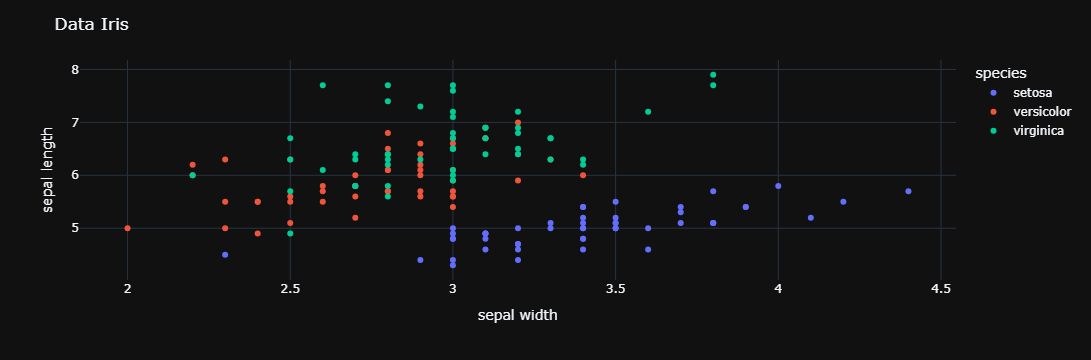

In [28]:
fig = px.scatter(df , x = 'sepal_width' , y = 'sepal_length' , color = 'species')
fig.update_layout(
    xaxis_title  = 'sepal width', 
    yaxis_title = 'sepal length', 
    title = 'Data Iris', 
    template = 'plotly_dark'
)

## 🔹 2. Using Graph Objects

> 👉 More control & customization

* Steps:
1. Import graph_objects
2. Create Figure()
3. Add traces manually

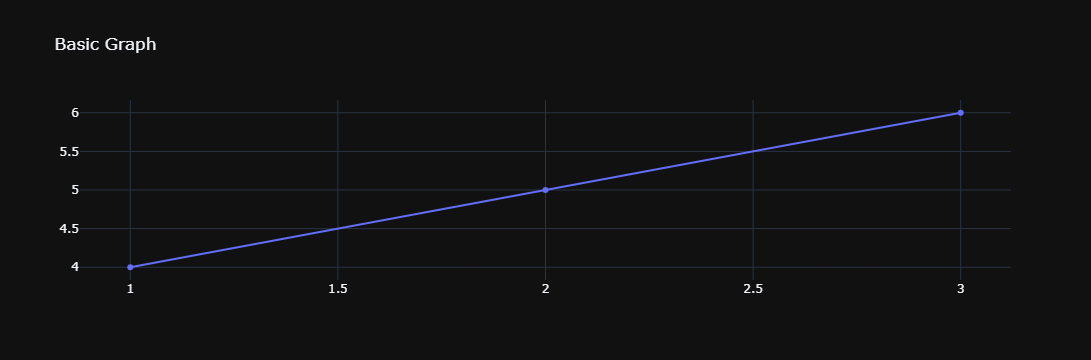

In [32]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[1, 2, 3],
    y=[4, 5, 6],
    mode='lines+markers'
))
fig.update_layout(
    title="Basic Graph",
    template = 'plotly_dark'
)

## 🔹 3. Figure Constructor Method

> 👉 Direct creation with data + layout

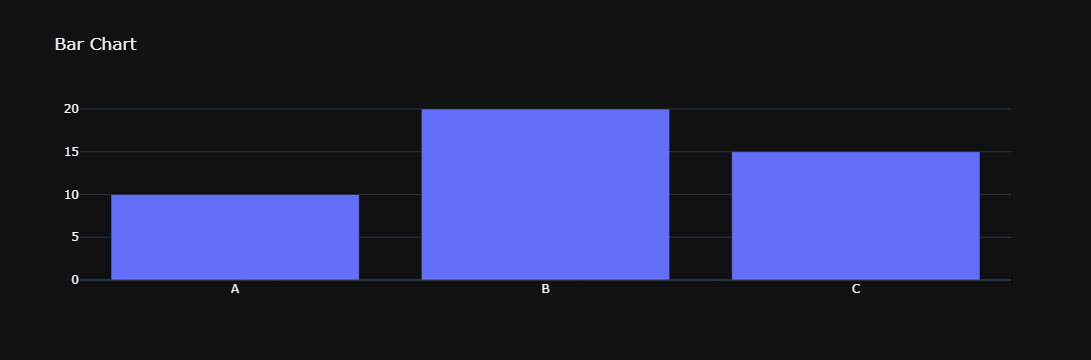

In [33]:
fig = go.Figure(
    data=[go.Bar(x=["A", "B", "C"], y=[10, 20, 15])],
    layout=go.Layout(title="Bar Chart", template='plotly_dark')
)

fig.show()

## 🔹 4. Using Figure Factories

> 👉 Pre-built complex charts (less used

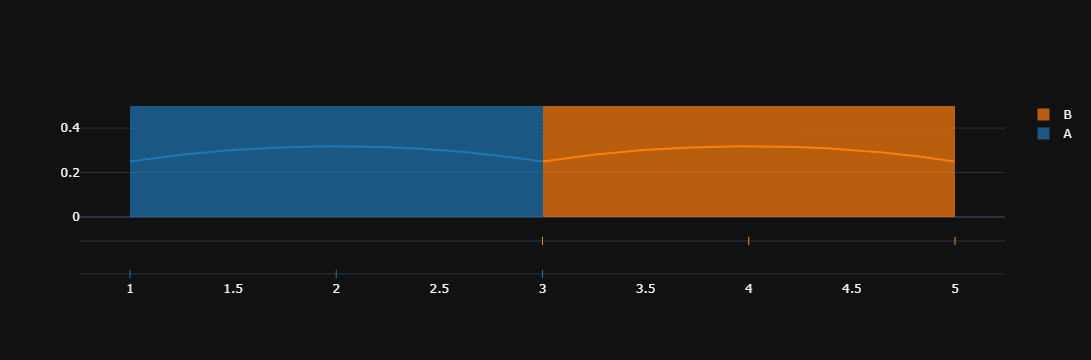

In [39]:
# import plotly.figure_factory as ff
data = [[1, 2, 3], [3, 4, 5]]
fig = ff.create_distplot(data , group_labels=['A' ,'B'])
fig.update_layout(template= 'plotly_dark')
fig.show()

## 🔹 5. Using Subplots (make_subplots)

> 👉 Multiple charts in one figure

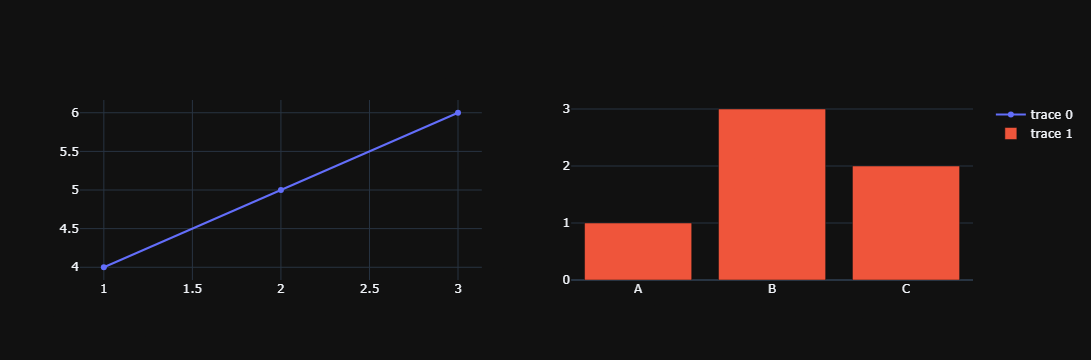

In [42]:
fig = make_subplots(rows=1, cols=2)

fig.add_trace(go.Scatter(x=[1,2,3], y=[4,5,6]), row=1, col=1)
fig.add_trace(go.Bar(x=["A","B","C"], y=[1,3,2]), row=1, col=2)
fig.update_layout(template= 'plotly_dark')
fig.show()

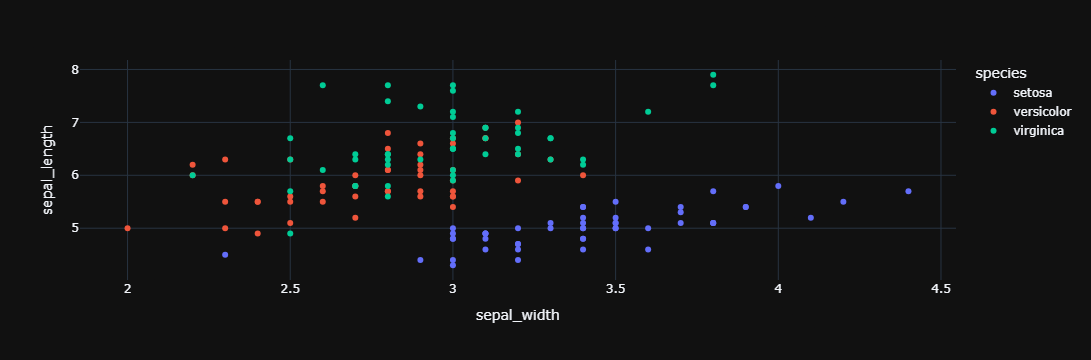

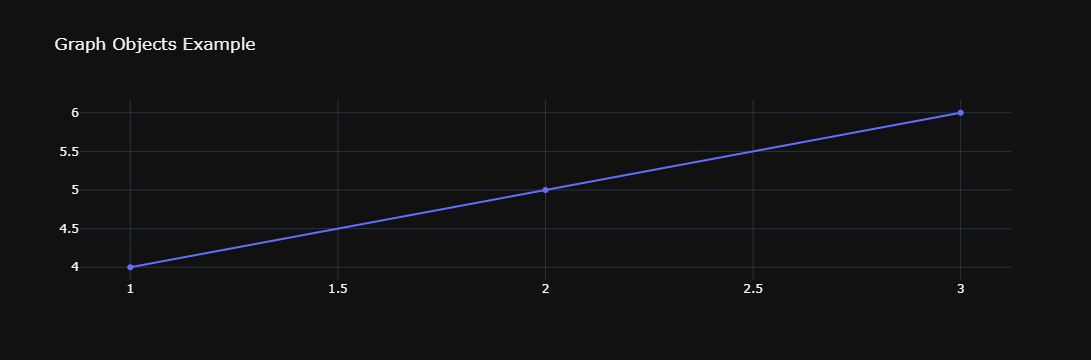

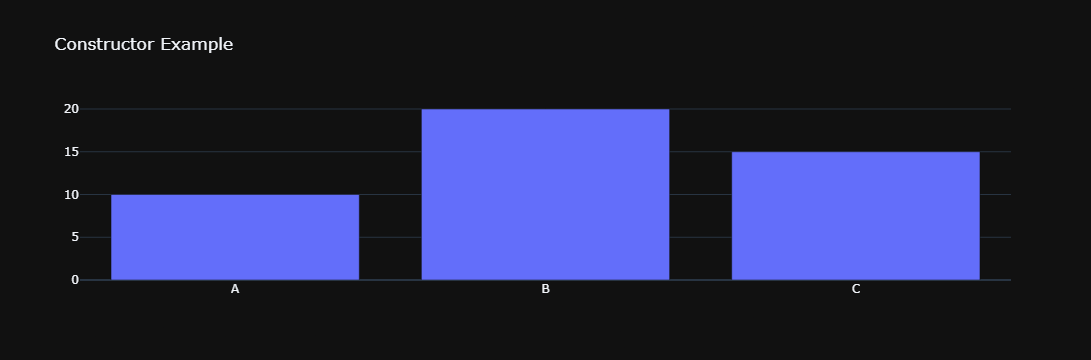

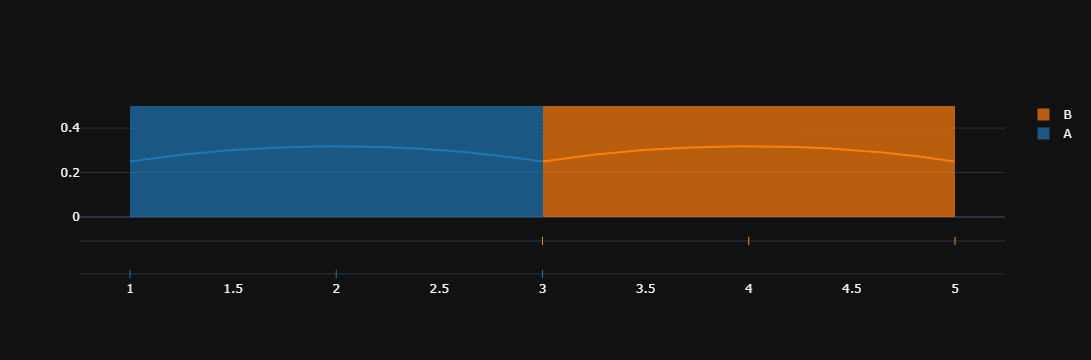

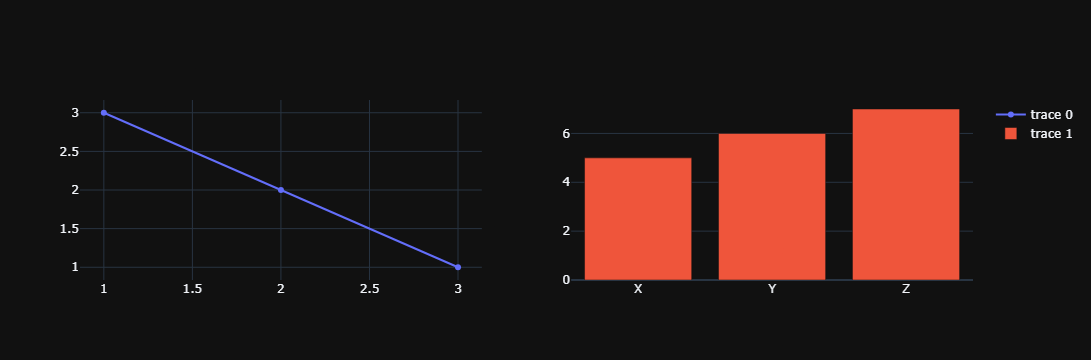

In [63]:
# 1. Plotly Express
df = px.data.iris()
fig1 = px.scatter(df, x="sepal_width", y="sepal_length", color="species")
fig1.update_layout(template = 'plotly_dark')

# 2. Graph Objects
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=[1,2,3], y=[4,5,6], mode='lines+markers', ))
fig2.update_layout(title="Graph Objects Example", template  = 'plotly_dark')

# 3. Constructor
fig3 = go.Figure(
    data=[go.Bar(x=["A","B","C"], y=[10,20,15])],
    layout=go.Layout(title="Constructor Example" , template = 'plotly_dark')
)

# 4. Figure Factory
data = [[1,2,3], [3,4,5]]
fig4 = ff.create_distplot(data, group_labels=["A","B"])
fig4.update_layout(template = 'plotly_dark')

# 5. Subplots
fig5 = make_subplots(rows=1, cols=2)
fig5.add_trace(go.Scatter(x=[1,2,3], y=[3,2,1]), row=1, col=1)
fig5.add_trace(go.Bar(x=["X","Y","Z"], y=[5,6,7]), row=1, col=2)
fig5.update_layout(template = 'plotly_dark')

# Show all
fig1.show()
fig2.show()
fig3.show()
fig4.show()
fig5.show()

---

# 📊 6: Plotly Express
>⚡ Core Idea
* Plotly Express is a high-level API in Plotly that lets you create complete figures in a single line.
> 👉 It automatically handles:


1. Data → traces
2. Layout → titles, axes
3. Colors → grouping

In [50]:
# import plotly.express as px

# df = px.data.iris()

# fig = px.scatter(
#     df,
#     x="sepal_width",
#     y="sepal_length",
#     color="species",
#     title="Iris Dataset",
#     labels={
#         "sepal_width": "Sepal Width",
#         "sepal_length": "Sepal Length"
#     },
#     template="plotly_dark"
# )
# fig.show()


## 🔹 Common Plot Types

1. px.line()
2. px.bar()
3. px.scatter()
4. px.histogram()
5. px.box()
6. px.pie()
---

# 📌  7. Graph Objects – Figure Constructor
>🔹 What it is
* The Figure Constructor in plotly.graph_objects lets you create a full chart in one step by passing:


1. data → traces (like Bar, Scatter, etc.)
2. layout → styling (title, axes, etc.)

> 👉 You can use:
1. Graph Objects (go.Bar, go.Scatter) for traces
2. Dictionary (dict) for layout

In [55]:
# import plotly.graph_objects as go

# # Create figure using constructor
# fig = go.Figure(
#     data=[
#         go.Bar(
#             x=[1, 2, 3],
#             y=[1, 3, 2]
#         )
#     ],
#     layout=dict(
#         title=dict(
#             text="A Figure Specified By A Graph Object"
#         )
#     )
# )

# # Show figure
# fig.show()

---

# 🏭 8. Figure Factories

> 🔹 What it is
* Figure Factories (plotly.figure_factory) are ready-made functions that create complex or specialized visualizations.
  
> 👉Instead of building everything manually, you call a function and get a fully constructed figure.

In [59]:
# import numpy as np

# 1. Create Grid Data
x1 , y1 = np.meshgrid(np.arange(0,2,0.2) , np.arange(0,2,0.2))

# 2. Define Vector Components 
u1 = np.cos(x1) * y1 
v1 = np.sin(x1) * y1 

> 👉 Here:

1. u1 → horizontal direction
2. v1 → vertical direction

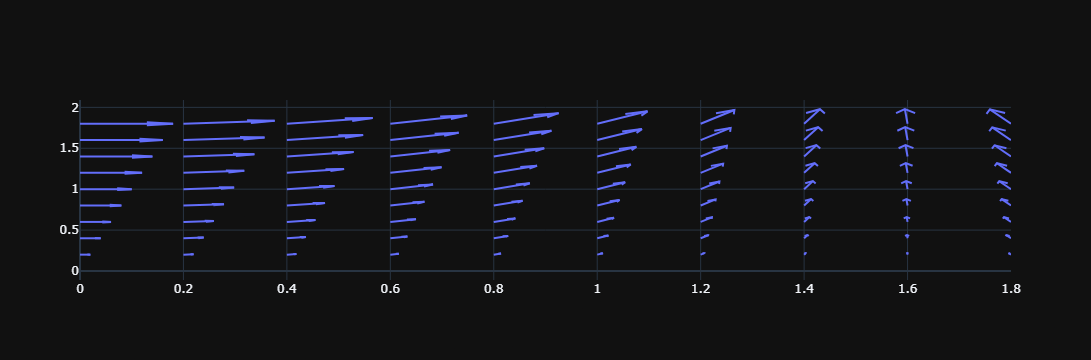

In [61]:
# 3. Create Quiver Plot

fig = ff.create_quiver(x1 , y1 , u1 , v1)
fig.update_layout(template= 'plotly_dark')
fig.show()

> 🚀 Simple Understanding

* This creates a vector field visualization where arrows show direction + magnitude.
---

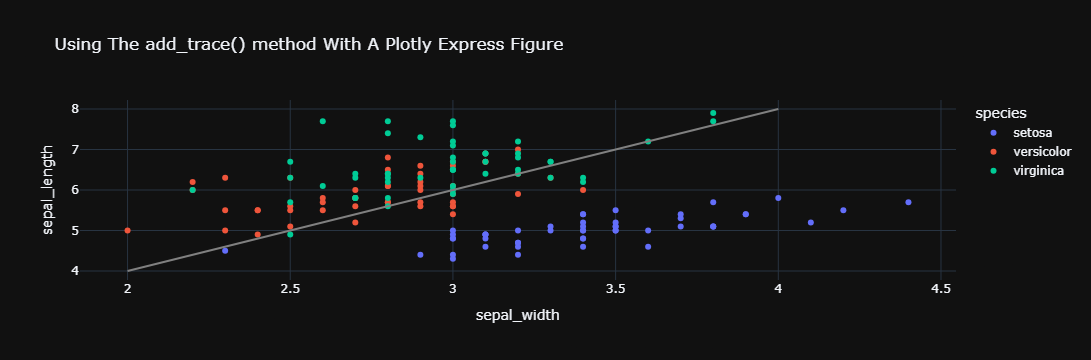

In [72]:
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species",
                 title="Using The add_trace() method With A Plotly Express Figure")

fig.add_trace(
    go.Scatter(
        x=[2, 4],
        y=[4, 8],
        mode="lines",
        line=go.scatter.Line(color="gray"),
        showlegend=False)
)


fig.update_layout(template = 'plotly_dark')
fig.show()

---

# 🗾 9. Adding Traces to Subplots


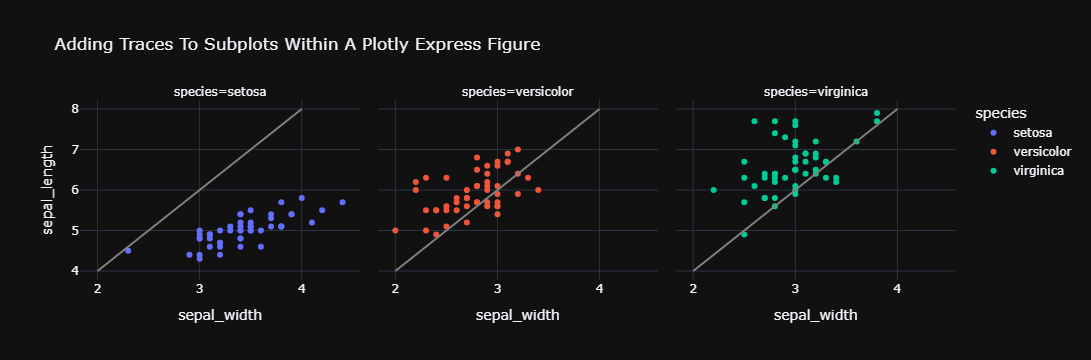

In [75]:
# Create subplots (facets)
fig = px.scatter(
    df,
    x="sepal_width",
    y="sepal_length",
    color="species",
    facet_col="species",
    title="Adding Traces To Subplots Within A Plotly Express Figure"
)

# Reference line
reference_line = go.Scatter(
    x=[2, 4],
    y=[4, 8],
    mode="lines",
    line=go.scatter.Line(color="gray"),
    showlegend=False
)

# Add to each subplot
fig.add_trace(reference_line, row=1, col=1)
fig.add_trace(reference_line, row=1, col=2)
fig.add_trace(reference_line, row=1, col=3)
fig.update_layout(template = 'plotly_dark')
fig.show()

---

# ⚡ 10. Magic Underscore Notation (Plotly Graph Objects)
> 🔹 What it is

* Magic underscore notation lets you avoid deeply nested dictionaries by writing properties in a flat, readable way using underscores.

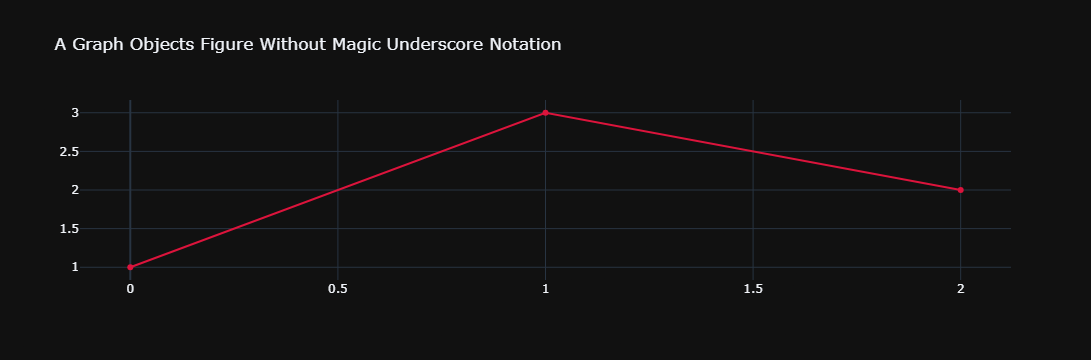

In [78]:
fig = go.Figure(
    data=[go.Scatter(y=[1, 3, 2], line=dict(color="crimson"))],
    layout_title_text ="A Graph Objects Figure Without Magic Underscore Notation"
)
fig.update_layout(template = 'plotly_dark')
fig.show()

---

# ⚡ 11. Updating Traces (update_traces())
> 🔹 What it is
* update_traces() lets you modify multiple traces at once without rewriting them.
  
>👉 Instead of editing each trace manually → update them in one line

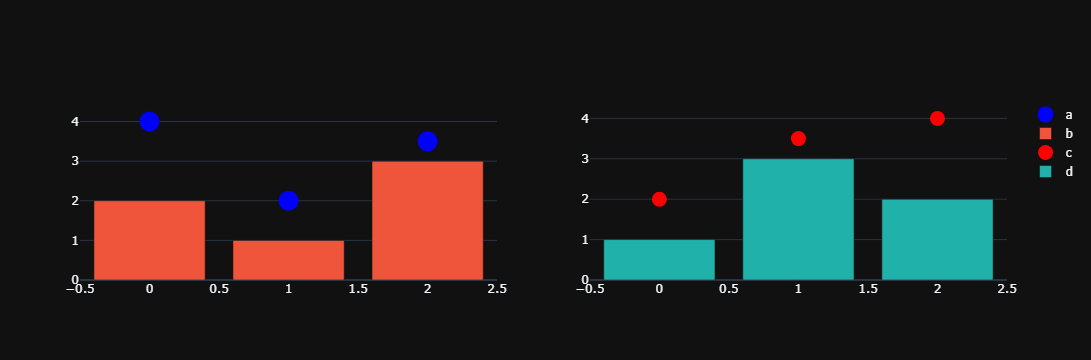

In [96]:
fig = make_subplots(rows = 1 , cols= 2)

fig.add_scatter(
    y=[4, 2, 3.5], mode="markers",
                marker=dict(size=20, color="LightSeaGreen"),
                name="a", row=1, col=1
)

fig.add_bar(
    y=[2, 1, 3],
            marker=dict(color="MediumPurple"),
            name="b", row=1, col=1
)
fig.add_scatter(y=[2, 3.5, 4], mode="markers",
                marker=dict(size=20, color="MediumPurple"),
                name="c", row=1, col=2)

fig.add_bar(y=[1, 3, 2],
            marker=dict(color="LightSeaGreen"),
            name="d", row=1, col=2)
fig.update_layout(template = 'plotly_dark')
fig.update_traces(marker_color="red", selector=dict(type="scatter"))
fig.update_traces(marker_color="blue", selector=dict(name="a"))
fig.update_traces(marker_color="light pink", selector=dict(name="b"))


## 🔹 Key Takeaways
1. update_traces() = bulk update traces
2. Use selector to target specific traces
3. Works perfectly with magic underscore notation
4. Essential for Dash dashboards & dynamic updates
> ⚡ One-Line Summary

* update_traces() = Edit multiple traces efficiently with 


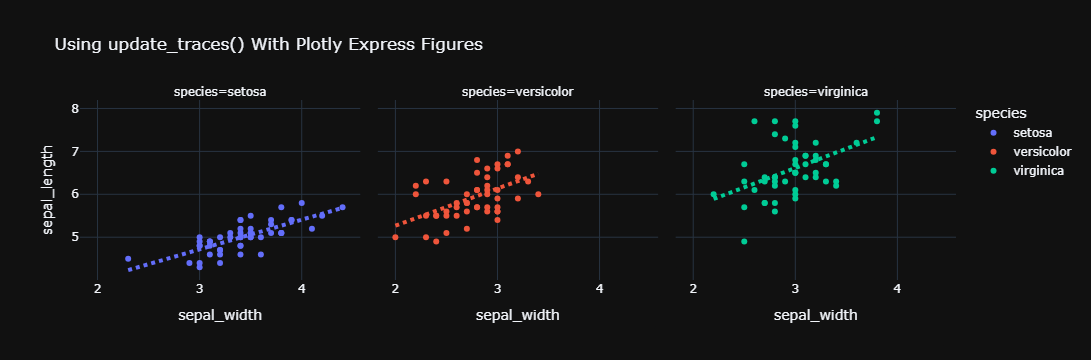

In [99]:
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species",
                 facet_col="species", trendline="ols", title="Using update_traces() With Plotly Express Figures")

fig.update_traces(
    line=dict(dash="dot", width=4),
    selector=dict(type="scatter", mode="lines"))
fig.update_layout(template = 'plotly_dark')
fig.show()

# Conditionally Updating Traces

fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species",
                 title="Conditionally Updating Traces In A Plotly Express Figure With for_each_trace()")

fig.for_each_trace(
    lambda trace: trace.update(marker_symbol="square") if trace.name == "setosa" else (),
)
fig.update_layout(template = 'plotly_dark')
fig.show()

---

# ⚡ 12.  Other Update Methods (Layout-Level Updates)
> 🔹 What it is

* Apart from update_traces(), Plotly provides methods to update non-trace elements like:

1. update_layout_images() → background images
2. update_annotations() → text labels/notes
3. update_shapes() → lines, rectangles, highlights

> 👉 These control the visual layers around your data

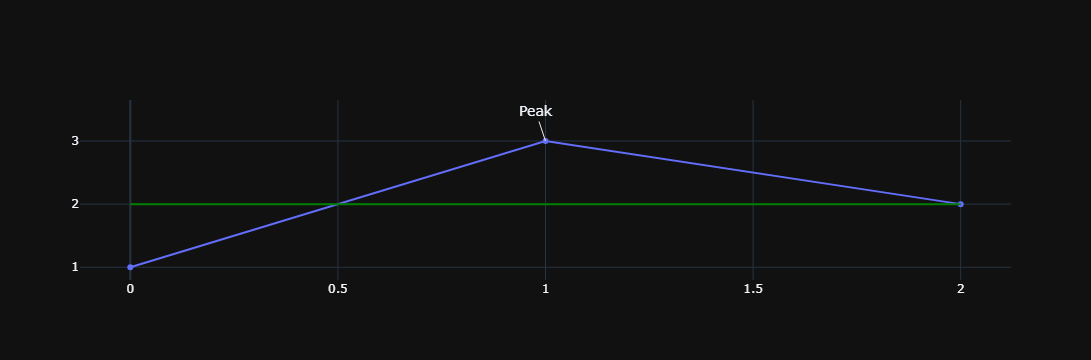

In [106]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_scatter(y=[1, 3, 2], mode="lines+markers")

# Annotation
fig.add_annotation(text="Peak", x=1, y=3, showarrow=True)

# Shape (threshold line)
fig.add_shape(type="line", x0=0, x1=2, y0=2, y1=2)

# Background image
fig.add_layout_image(
    dict(
        source="https://images.plotly.com/language-icons/api-home/python-logo.png",
        xref="paper", yref="paper",
        x=0.5, y=0.5,
        sizex=0.6, sizey=0.6,
        opacity=0.2
    )
)

# Update everything cleanly
fig.update_annotations(font_size=14)
fig.update_shapes(line_color="green")
fig.update_layout_images(opacity=0.05)
fig.update_layout(template = 'plotly_dark')
fig.show()

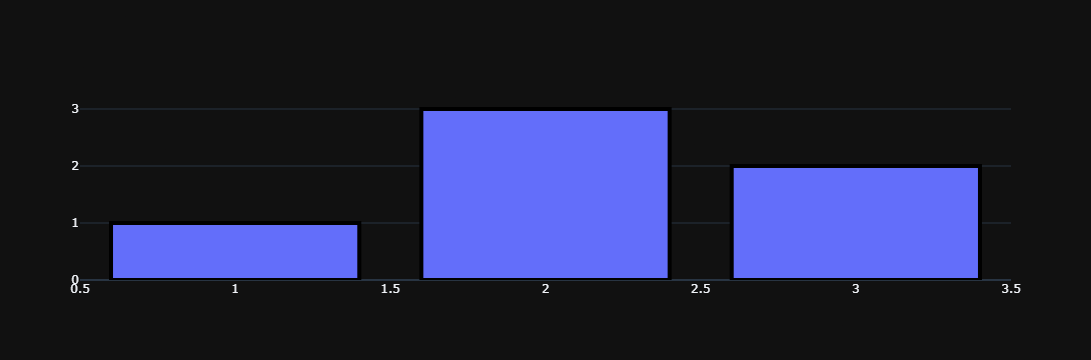

In [108]:

fig = go.Figure(data=go.Bar(x=[1, 2, 3], y=[1, 3, 2]))

fig.data[0].marker.line.width = 4
fig.data[0].marker.line.color = "black"
fig.update_layout(template = 'plotly_dark')
fig.show()